In [1]:
import os
import pandas as pd
import numpy as np
from statsmodels.stats.inter_rater import fleiss_kappa

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    cohen_kappa_score,
    classification_report
)

import matplotlib.pyplot as plt
from collections import Counter

In [2]:
file_mapping = {'file1': 'MATAVE', 'file2': 'LDA'}

results_dir = "./results/"
labels_dir = "./labels/"

In [3]:
agreement_mapping = {}

for folder in os.listdir(results_dir):
    folder_path = os.path.join(results_dir, folder)

    if not os.path.isdir(folder_path):
        continue

    for file in os.listdir(folder_path):

        key = file.replace('UnlabelledNotes.xlsx', '')

        df = pd.read_excel(os.path.join(folder_path, file))

        agreement_mapping.setdefault(key, []).append(df)

/Users/isabel/anaconda3/envs/localSyntheticData/lib/python3.12/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)
/Users/isabel/anaconda3/envs/localSyntheticData/lib/python3.12/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)
/Users/isabel/anaconda3/envs/localSyntheticData/lib/python3.12/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)
/Users/isabel/anaconda3/envs/localSyntheticData/lib/python3.12/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)
/Users/isabel/anaconda3/envs/localSyntheticData/lib/python3.12/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)


In [4]:
agreement_mapping

{'file1': [                                                report  needs comments
  0    Emma's evening medication has been administere...    met      NaN
  1    Olivia attended her session today with great e...    met      NaN
  2    Resident Mr... Peter was able to attend his ph...    met      NaN
  3    John's sister Mary came to visit him today, br...    met      NaN
  4    Nurse Mark visited John today for routine vita...    met      NaN
  ..                                                 ...    ...      ...
  227  Ms Smith needed help getting clean today due t...  unmet      NaN
  228  Resident John was assisted to the bathroom thi...  unmet      NaN
  229  The patient reported discomfort in their abdom...  unmet      NaN
  230  Resident's diet remains nil by mouth; however,...    met      NaN
  231  Robert has difficulty communicating his needs ...  unmet      NaN
  
  [232 rows x 3 columns],
                                                  report  needs  \
  0    Emma's eveni

In [19]:
for file, raters in agreement_mapping.items():

    print("---------------------------------------------")
    print(f"----------- {file_mapping[file]} -----------")
    print("---------------------------------------------")

    rater_cols = [df['needs'] for df in raters]

    temp_dict = {
        f"rater_{i}": r for i, r in enumerate(rater_cols)
    }
    print(len(temp_dict["rater_0"]))
    ratings = pd.DataFrame(temp_dict).dropna()
    print(len(ratings["rater_0"]))
    categories = sorted(pd.unique(ratings.values.ravel()))

    fleiss_matrix = []

    for _, row in ratings.iterrows():
        counts = [(row == cat).sum() for cat in categories]
        fleiss_matrix.append(counts)

    fleiss_matrix = np.array(fleiss_matrix)

    n_raters = len(rater_cols)

    assert np.all(
        fleiss_matrix.sum(axis=1) == n_raters
    ), "Mismatch in number of raters per item"

    kappa = fleiss_kappa(fleiss_matrix)

    print(f"Fleiss' kappa ({file_mapping[file]}): {kappa}\n")

---------------------------------------------
----------- MATAVE -----------
---------------------------------------------
232
222
Fleiss' kappa (MATAVE): 0.6555851063829785

---------------------------------------------
----------- LDA -----------
---------------------------------------------
240
233
Fleiss' kappa (LDA): 0.6830062664907653



In [20]:
def get_rater_scores(model, human, title, file_name):
    results_dict = {
        "model": file_name.split('_')[0],
        "Accuracy": accuracy_score(human, model),
        "Precision": precision_score(human, model, pos_label='unmet'),
        "Recall": recall_score(human, model, pos_label='unmet'),
        "F1 Score": f1_score(human, model, pos_label='unmet'),
        "Cohen's Kappa": cohen_kappa_score(human, model),

    }
    results_df = pd.DataFrame(results_dict, columns=results_dict.keys(), index=[file_name.split('_')[0]])
    
    for key, value in results_dict.items():
        print(f"{key}: {value}")
    print()

    print(classification_report(human, model))

    cm = confusion_matrix(human, model, labels=['met', 'unmet'])

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['met', 'unmet']
    )

    disp.plot()

    plt.xlabel('Model Labels')
    plt.ylabel('Human Labels')
    plt.title(title)

    os.makedirs("./graphs/", exist_ok=True)
    plt.savefig(f"./graphs/{file_name}.png")

    plt.show()
    return results_df

In [15]:
def majority_votes(comparison_df):
    def majority_vote(row):    
        votes = [row[col] for col in row.index if col.startswith('rater')]
        count = Counter(votes)
        return count.most_common(1)[0][0]

    comparison_df['majority_vote'] = comparison_df[[col for col in comparison_df.columns if col.startswith('rater')]].apply(majority_vote, axis=1)
    return comparison_df

---------------------------------------------
----------- MATAVE -----------
---------------------------------------------
model: MATAVE
Accuracy: 0.8153153153153153
Precision: 0.8913043478260869
Recall: 0.7256637168141593
F1 Score: 0.8
Cohen's Kappa: 0.631766324136257

              precision    recall  f1-score   support

         met       0.76      0.91      0.83       109
       unmet       0.89      0.73      0.80       113

    accuracy                           0.82       222
   macro avg       0.83      0.82      0.81       222
weighted avg       0.83      0.82      0.81       222



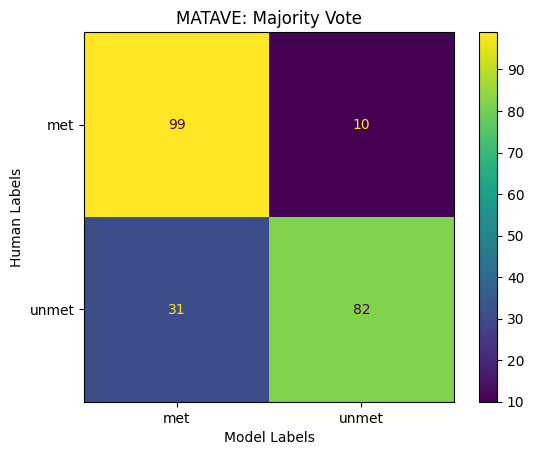

---------------------------------------------
----------- LDA -----------
---------------------------------------------
model: LDA
Accuracy: 0.927038626609442
Precision: 0.9032258064516129
Recall: 0.9572649572649573
F1 Score: 0.9294605809128631
Cohen's Kappa: 0.8540369237572318

              precision    recall  f1-score   support

         met       0.95      0.90      0.92       116
       unmet       0.90      0.96      0.93       117

    accuracy                           0.93       233
   macro avg       0.93      0.93      0.93       233
weighted avg       0.93      0.93      0.93       233



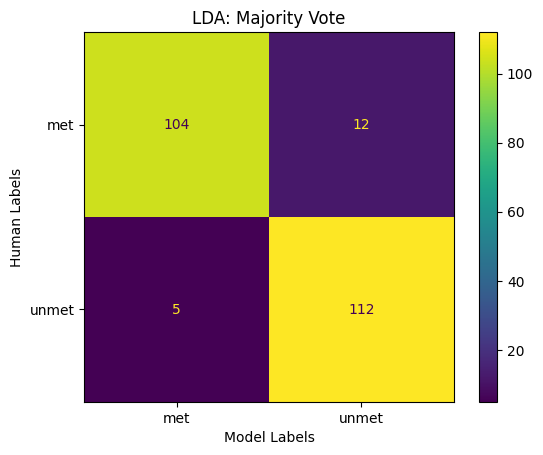

model: allTopicModels
Accuracy: 0.8725274725274725
Precision: 0.8981481481481481
Recall: 0.8434782608695652
F1 Score: 0.8699551569506726
Cohen's Kappa: 0.7451964854687652

              precision    recall  f1-score   support

         met       0.85      0.90      0.88       225
       unmet       0.90      0.84      0.87       230

    accuracy                           0.87       455
   macro avg       0.87      0.87      0.87       455
weighted avg       0.87      0.87      0.87       455



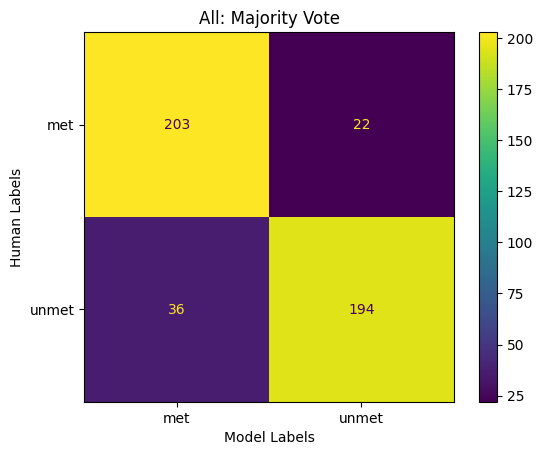

In [16]:
all_human = []
all_model = []
results_dfs = []
for file, raters in agreement_mapping.items():

    print("---------------------------------------------")
    print(f"----------- {file_mapping[file]} -----------")
    print("---------------------------------------------")

    gpt_raters = [df['needs'] for df in raters]

    human = pd.read_excel(
        f"{labels_dir}{file_mapping[file]}_labelled_notes.xlsx"
    )['needs']

    temp_dict = {
        f"rater_{i}": r for i, r in enumerate(gpt_raters)
    }

    temp_dict["real"] = human

    ratings = pd.DataFrame(temp_dict).dropna()

    # model = ratings["rater_0"]
    # human_clean = ratings["real"]

    # get_rater_scores(
    #     model,
    #     human_clean,
    #     title=f"{file_mapping[file]}: Rater 0",
    #     file_name=f"{file_mapping[file]}_rater0"
    # )

    # model = ratings["rater_1"]
    # human_clean = ratings["real"]

    # get_rater_scores(
    #     model,
    #     human_clean,
    #     title=f"{file_mapping[file]}: Rater 1",
    #     file_name=f"{file_mapping[file]}_rater1"
    # )

    # model = ratings["rater_2"]
    # human_clean = ratings["real"]

    # get_rater_scores(
    #     model,
    #     human_clean,
    #     title=f"{file_mapping[file]}: Rater 2",
    #     file_name=f"{file_mapping[file]}_rater2"
    # )

    clean_majority = majority_votes(ratings)

    human_clean = clean_majority['majority_vote']
    model = ratings["real"]

    results_dfs.append(get_rater_scores(
        human_clean,
        model,
        title=f"{file_mapping[file]}: Majority Vote",
        file_name=f"{file_mapping[file]}_majority"
    ))

    all_human.extend(human_clean.tolist())
    all_model.extend(model.tolist())

results_dfs.append(get_rater_scores(
    all_human,
    all_model,
    title=f"All: Majority Vote",
    file_name=f"allTopicModels_majority"
))


In [17]:
results_dfs

[         model  Accuracy  Precision    Recall  F1 Score  Cohen's Kappa
 MATAVE  MATAVE  0.815315   0.891304  0.725664       0.8       0.631766,
     model  Accuracy  Precision    Recall  F1 Score  Cohen's Kappa
 LDA   LDA  0.927039   0.903226  0.957265  0.929461       0.854037,
                          model  Accuracy  Precision    Recall  F1 Score  \
 allTopicModels  allTopicModels  0.872527   0.898148  0.843478  0.869955   
 
                 Cohen's Kappa  
 allTopicModels       0.745196  ]

In [18]:
all_results_final = pd.concat(results_dfs)

In [11]:
(all_results_final).to_csv('./humanResults.csv')

In [12]:
all_results_final

,model,Accuracy,Precision,Recall,F1 Score,Cohen's Kappa
MATAVE,MATAVE,0.815315,0.891304,0.725664,0.800000,0.631766
LDA,LDA,0.927039,0.903226,0.957265,0.929461,0.854037
allTopicModels,allTopicModels,0.872527,0.898148,0.843478,0.869955,0.745196
